Missing Values


3 mechanisms

### 1 Missing Completely at Random, MCAR:
Missing completely at random (MCAR) is a type of missing data mechanism in which the probability of a value being missing is unrelated to both the observed data and the missing data. In other words, if the data is MCAR, the missing values are randomly distributed throughout the dataset, and there is no systematic reason for why they are missing.

For example, in a survey about the prevalence of a certain disease, the missing data might be MCAR if the survey participants with missing values for certain questions were selected randomly and their missing responses are not related to their disease status or any other variables measured in the survey.


### 2. Missing at Random MAR:
Missing at Random (MAR) is a type of missing data mechanism in which the probability of a value being missing depends only on the observed data, but not on the missing data itself. In other words, if the data is MAR, the missing values are systematically related to the observed data, but not to the missing data.
Here are a few examples of missing at random:

Income data: Suppose you are collecting income data from a group of people, but some participants choose not to report their income. If the decision to report or not report income is related to the participant's age or gender, but not to their income level, then the data is missing at random.

Medical data: Suppose you are collecting medical data on patients, including their blood pressure, but some patients do not report their blood pressure. If the patients who do not report their blood pressure are more likely to be younger or have healthier lifestyles, but the missingness is not related to their actual blood pressure values, then the data is missing at random.

## 3. Missing data not at random (MNAR) 
It is a type of missing data mechanism where the probability of missing values depends on the value of the missing data itself. In other words, if the data is MNAR, the missingness is not random and is dependent on unobserved or unmeasured factors that are associated with the missing values.

For example, suppose you are collecting data on the income and job satisfaction of employees in a company. If employees who are less satisfied with their jobs are more likely to refuse to report their income, then the data is not missing at random. In this case, the missingness is dependent on job satisfaction, which is not directly observed or measured.

In [62]:
import seaborn as sns
df=sns.load_dataset('titanic')
 

In [63]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [5]:
## check missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
## Delete the rows or data point to handle missing values
df.shape

(891, 15)

In [ ]:
df.dropna().shape ## more data is lossed , so not prefered

(182, 15)

In [9]:
## Delete col wise
df.dropna(axis=1)

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


Imputation Techniques

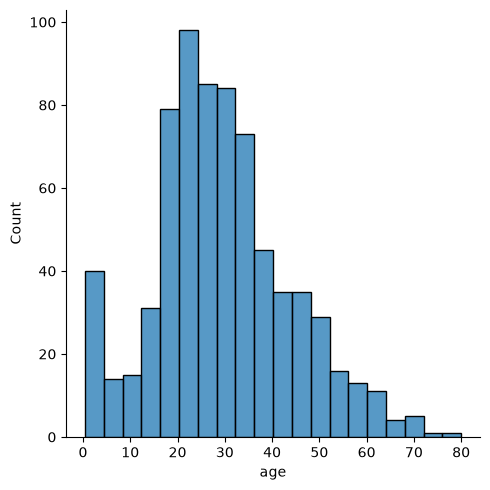

In [10]:
## Mean Value Imputation
sns.displot(df['age'])

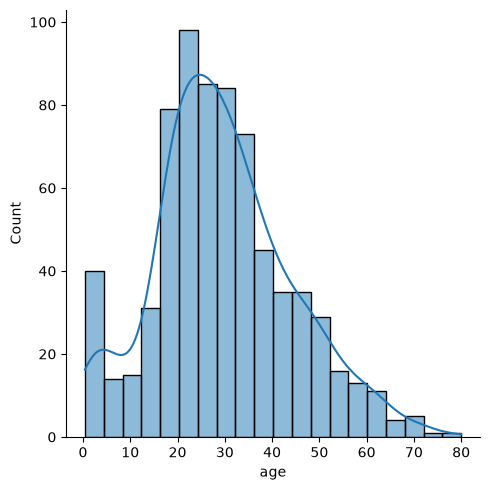

In [11]:
sns.displot(df['age'],kde=True)

In [12]:
df["Age_mean"]=df['age'].fillna(df['age'].mean())

In [ ]:
## mean imputation works well when we have normally distributed data

Median Imputation

if we have outliers in the dataset i.e left skewed or right skewed

In [13]:
df['age_median']=df['age'].fillna(df['age'].median())

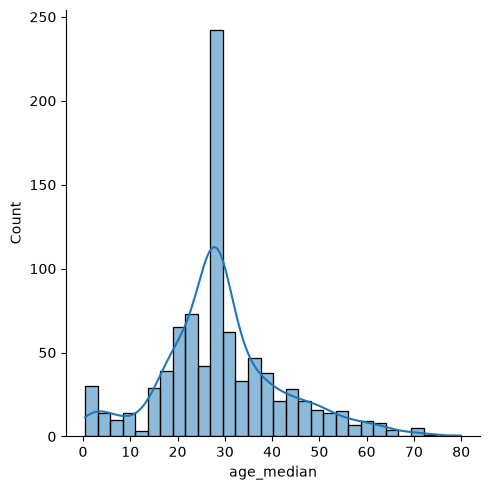

In [14]:
sns.displot(df['age_median'],kde=True)

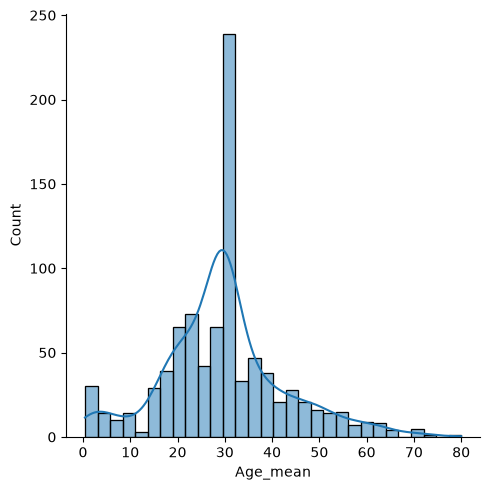

In [16]:
sns.displot(df['Age_mean'],kde=True)

In [17]:
## mode imputation -- for categorial values

In [64]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True


In [19]:
df['embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [65]:
df['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [68]:
mode_value=df[df['embarked'].notna()]['embarked'].mode()[0]
mode_value

'S'

In [22]:
df['embarked_mode']=df['embarked'].fillna(mode_value)

Imbalanced Dataset

1. Up Sampling
2. Down Sampling

In [1]:
import numpy as np
import pandas as pd

# Set the random seed for reproducibility
np.random.seed(123)

n_samples=1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1=n_samples-n_class_0

In [2]:
n_class_0,n_class_1

(900, 100)

In [3]:
## create my dataframe with imbalanced dataset
class_0=pd.DataFrame({
    'feature_1':np.random.normal(loc=0,scale=1,size=n_class_0),
    'feature_2':np.random.normal(loc=0,scale=1,size=n_class_0),
    'target':[0]*n_class_0
})
class_1=pd.DataFrame({
    'feature_1':np.random.normal(loc=0,scale=1,size=n_class_1),
    'feature_2':np.random.normal(loc=0,scale=1,size=n_class_1),
    'target':[1]*n_class_1
})

In [5]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)

In [6]:
df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [7]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [8]:
## upsampling
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [18]:
from sklearn.utils import resample

In [19]:
df_minority_upscale=resample(df_minority,replace=True,
         n_samples=len(df_majority),
         random_state=42)

In [20]:
df_minority_upscale.head()

,feature_1,feature_2,target
951,-0.874146,-0.156083,1
992,0.196570,-0.602575,1
914,-0.067830,0.998053,1
971,0.272825,1.034197,1
960,0.870056,-0.449515,1


In [21]:
df_upsamples=pd.concat([df_majority,df_minority_upscale])

In [22]:
df_upsamples.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [25]:
df_upsamples['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [26]:
#Downsampling
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [27]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [28]:
df_majority_downscale=resample(df_majority,replace=False,
         n_samples=len(df_minority),
         random_state=42)

In [29]:
df_majority_downscale.shape

(100, 3)

In [30]:
df_downsamples=pd.concat([df_minority,df_majority_downscale])

SMOTE(Synthetic Minority Oversampling Technique)

SMOTE is a technique used in machine learning to address imbalanced datasets where the minority class has significantly fewer instances than the majority class. SMOTE involves generating synthetic instances of the minority class by interpolating btw existing instances.

In [42]:
from sklearn.datasets import make_classification
X,Y=make_classification(n_samples=1000,n_features=2,n_clusters_per_class=1,weights=[0.90],random_state=12,n_redundant=0)

In [43]:
import pandas as pd
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(Y,columns=['target'])
df=pd.concat([df1,df2],axis=1)

In [44]:
df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [45]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

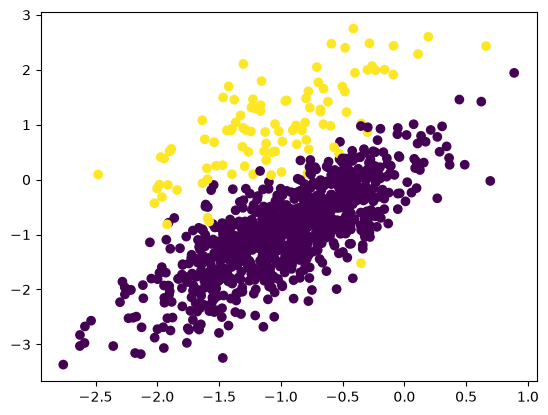

In [46]:
import matplotlib.pyplot as plt
plt.scatter(df['f1'],df['f2'],c=df['target'])

In [49]:
pip install imblearn

  Obtaining dependency information for imblearn from https://files.pythonhosted.org/packages/81/a7/4179e6ebfd654bd0eac0b9c06125b8b4c96a9d0a8ff9e9507eb2a26d2d7e/imblearn-0.0-py2.py3-none-any.whl.metadata
  Obtaining dependency information for imbalanced-learn from https://files.pythonhosted.org/packages/91/54/760ccac7d8feeea0c191767a6b025d3ca5014084443ff48afb6fb24ef056/imbalanced_learn-0.14.2-py3-none-any.whl.metadata
  Obtaining dependency information for sklearn-compat<0.2,>=0.1.6 from https://files.pythonhosted.org/packages/b0/20/47a7e947757008be1b77f1c6a6861d26a84ef4b4ea3e6ebf4eff24f24d5d/sklearn_compat-0.1.6-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/236.1 kB ? eta -:--:--
   - -------------------------------------- 10.2/236.1 kB ? eta -:--:--
   ---------- ---------------------------- 61.4/236.1 kB 825.8 kB/s eta 0:00:01
   ---------- ---------------------------- 61.4/236.1 kB 825.8 kB/s eta 0:00:01
   ------------------- ------------------ 122.9/236


[notice] A new release of pip is available: 23.2.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
from imblearn.over_sampling import SMOTE


In [51]:
import sys
!{sys.executable} -m pip install -U imbalanced-learn


[notice] A new release of pip is available: 23.2.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
oversample=SMOTE()
x,y=oversample.fit_resample(df[['f1','f2']],df['target'])

In [55]:
x.shape

(1800, 2)

In [56]:
len(y[y==0])

900

In [59]:
import pandas as pd
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
df_new=pd.concat([df1,df2],axis=1)

In [60]:
df_new['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

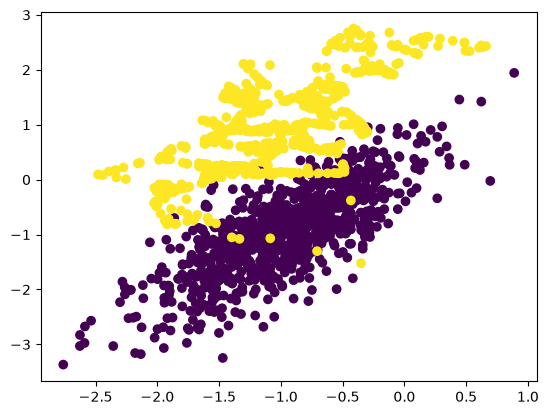

In [61]:
plt.scatter(df_new['f1'],df_new['f2'],c=df_new['target'])

Outliers

In [69]:
## 5 number summary
lst_marks=[45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74]
minimum,q1,median,q3,maximum=np.quantile(lst_marks,[0,0.25,0.50,0.75,1.0])

In [70]:
minimum,q1,median,q3,maximum

(np.float64(32.0),
 np.float64(54.0),
 np.float64(67.0),
 np.float64(89.0),
 np.float64(99.0))

In [71]:
iqr=q3-q1
print(iqr)

35.0


In [72]:
lower_fence=q1-1.5*iqr
higher_fence=q3+1.5*iqr

<Axes: >

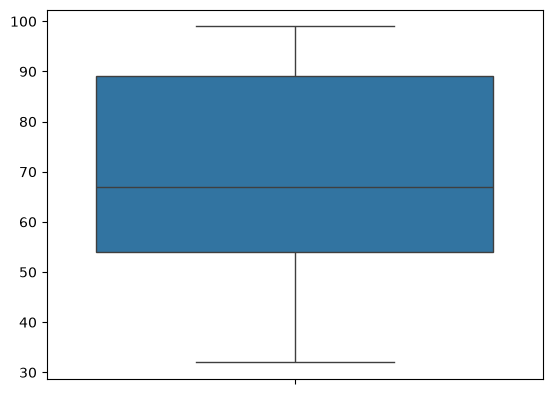

In [73]:
import seaborn as sns
sns.boxplot(lst_marks)

In [74]:
lst_marks=[-100,-200,45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74,200,300]

<Axes: >

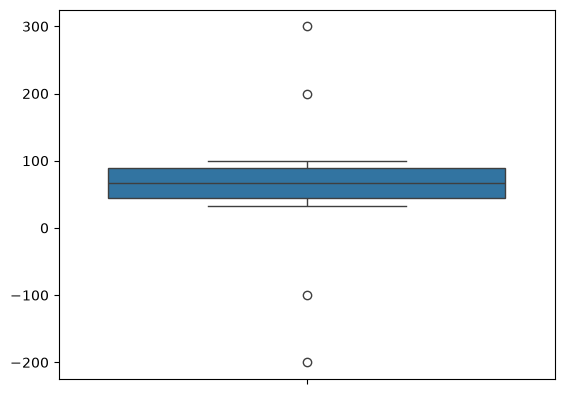

In [75]:
sns.boxplot(lst_marks)

Data Encoding --- converting categorial feature into meaningful numerical 

1. Nominal/OHE Encoding
2. label and Ordinal Encoding
3. Target Guided Ordinal Encoding

Nominal/OHE

one hot encoding

ex) color (red,green,blue)
red [1,0,0]
green [0,1,0]
Blue [0,0,1]

new feature are added red green blue

In [76]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [77]:
df=pd.DataFrame({
    'color':['red','blue','green','green','red']
    
})

In [78]:
df

,color
0,red
1,blue
2,green
3,green
4,red


In [79]:
ohe=OneHotEncoder()

In [80]:
ohe.fit_transform(df[['color']])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (5, 3)>

In [81]:
encoder=ohe.fit_transform(df[['color']]).toarray()

In [82]:
encoder

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [83]:
import pandas as pd
df_encoder=pd.DataFrame(encoder,columns=ohe.get_feature_names_out())

In [84]:
df_encoder

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0


In [85]:
ohe.transform([['blue']]).toarray()

c:\Users\dheer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[1., 0., 0.]])

In [87]:
df=pd.concat([df,df_encoder],axis=1)

In [88]:
df

,color,color_blue,color_green,color_red
0,red,0.0,0.0,1.0
1,blue,1.0,0.0,0.0
2,green,0.0,1.0,0.0
3,green,0.0,1.0,0.0
4,red,0.0,0.0,1.0


In [89]:
df=pd.DataFrame({
    'color':['red','blue','green','green','red']
    
})
from sklearn.preprocessing import LabelEncoder

In [90]:
lbl_encoder=LabelEncoder()
lbl_encoder.fit_transform(df[['color']])

c:\Users\dheer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([2, 0, 1, 1, 2])

In [91]:
lbl_encoder.transform([['red']])

c:\Users\dheer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([2])

In [92]:
## ordinal encoding
df = pd.DataFrame({
    'size':['small','medium','small','large','large']
    
})


In [93]:
df

,size
0,small
1,medium
2,small
3,large
4,large


In [ ]:
from sklearn.preprocessing import OrdinalEncoder


In [96]:
Encoder=OrdinalEncoder(categories=[['small','medium','large']])

In [97]:
Encoder.fit_transform(df[['size']])

array([[0.],
       [1.],
       [0.],
       [2.],
       [2.]])

Target Guided Ordinal Encoding

In [99]:
import pandas as pd

df=pd.DataFrame({
    'city':['NewYork','London','Paris','Tokyo','NewYork',"Paris"],
    'price':[200,150,300,250,180,320]
})

In [100]:
df

,city,price
0,NewYork,200
1,London,150
2,Paris,300
3,Tokyo,250
4,NewYork,180
5,Paris,320


In [101]:
mean_price=df.groupby('city')['price'].mean().to_dict()

In [102]:
mean_price

{'London': 150.0, 'NewYork': 190.0, 'Paris': 310.0, 'Tokyo': 250.0}

In [103]:
df['city_encoded']=df['city'].map(mean_price)

In [104]:
df

,city,price,city_encoded
0,NewYork,200,190.0
1,London,150,150.0
2,Paris,300,310.0
3,Tokyo,250,250.0
4,NewYork,180,190.0
5,Paris,320,310.0
